# Homework 4: Functions, Tables, and Groups

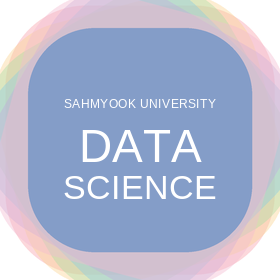

Please complete this notebook by filling in the cells provided. Before you begin, execute the previous cell to load the provided tests.

**Helpful Resource:**
- [Python Reference](http://data8.org/sp26/reference/): Cheat sheet of helpful array & table methods used in this data science course!

**Recommended Readings**: 

* [Visualizing Numerical Distributions](https://www.inferentialthinking.com/chapters/07/2/Visualizing_Numerical_Distributions.html)
* [Functions and Tables](https://www.inferentialthinking.com/chapters/08/Functions_and_Tables.html)

Please complete this notebook by filling in the cells provided. **Before you begin, execute the cell below to setup the notebook by importing some helpful libraries.** Each time you start your server, you will need to execute this cell again.

For all problems that you must write explanations and sentences for, you **must** provide your answer in the designated space. Moreover, throughout this homework and all future ones, **please be sure to not re-assign variables throughout the notebook!** For example, if you use `max_temperature` in your answer to one question, do not reassign it later on. Otherwise, you will fail tests that you thought you were passing previously!

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged.

You should start early so that you have time to get help if you're stuck.

In [ ]:
# Setup (run this first!)
!pip install -q otter-grader datascience
!git clone https://github.com/jihyungkim94/datascience.git 2>/dev/null || true
import os, json
os.chdir('/content/datascience/hw/hw04')
os.makedirs('tests', exist_ok=True)
with open('hw04.ipynb') as _f:
    _nb = json.load(_f)
for _name, _test in _nb['metadata']['otter']['tests'].items():
    with open('tests/' + _name + '.py', 'w') as _f:
        _f.write('OK_FORMAT = True\n\ntest = ' + repr(_test) + '\n')
import otter
grader = otter.Notebook('hw04.ipynb')
print('Ready! (14 tests loaded)')

---

The point breakdown for this assignment is given in the table below:
| Category | Points |
| --- | --- |
| Autograder (Coding questions) | 88 |
| Written | 12 |
| **Total** | 100 |


<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 1. 2023 Cal Football Season

In [ ]:
# Run this cell to set up the notebook, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import warnings
warnings.simplefilter('ignore', FutureWarning)
warnings.filterwarnings("ignore")

Marissa and Tiffany are trying to analyze how well the Cal football team performed in the 2023 season. A football game is divided into four periods, called quarters. The number of points Cal scored in each quarter and the number of points their opponent scored in each quarter are stored in a table called `cal_fb.csv`.

In [ ]:
# Just run this cell
# Read in the cal_fb csv file
games = Table().read_table("cal_fb.csv")
games.show()

Let's start by finding the total points each team scored in a game.

---

**Question 1.1.** Write a function called `sum_scores`.  It should take in four arguments, where each argument represents an integer corresponding to the team's score for each quarter. It should return the team's total score for that game as an integer. **(2 Points)**

*Hint:* Don't overthink this question!



In [ ]:
def sum_scores(..., ..., ..., ...):
    '''Returns the total score calculated by adding up the score of each quarter'''
    ...

sum_scores(14, 7, 3, 0) #DO NOT CHANGE THIS LINE

In [ ]:
grader.check("q1_1")

---

**Question 1.2.** Create a new table `final_scores` with three columns in this *specific* order: `Opponent`, `Cal Score`, `Opponent Score`. You will have to create the `Cal Score` and `Opponent Score` columns. Use the function `sum_scores` you just defined in the previous question for this problem. **(4 Points)**

*Hint:* If you want to apply a function that takes in multiple arguments, you can pass multiple column names as arguments in `tbl.apply()`. The column values will be passed into the corresponding arguments of the function. Take a look at the [Python Reference](https://www.data8.org/sp26/reference/)  and Lecture 9's demo for syntax.

*Note:* If you’re running into issues creating `final_scores`, check that `cal_scores` and `opp_scores` output what you want. If you're encountering `TypeError`s, check the [Python Reference](https://www.data8.org/sp26/reference/) to see if the inputs/outputs of the function are what you expect.


In [ ]:
cal_scores = ...
opp_scores = ...
final_scores = ...
final_scores

In [ ]:
grader.check("q1_2")

We can get specific row objects from a table. You can use `tbl.row(n)` to get the `n`th row of a table. `row.item("column_name")` will allow you to select the element that corresponds to `column_name` in a particular row. Here's an example:

In [ ]:
# Just run this cell
# We got the Axe!
games.row(10) # <-- this will return a row object

In [ ]:
# Just run this cell
games.row(10).item("Cal 4Q") # <-- this will return a item (e.g. an int) from a row object

---

**Question 1.3.** We want to see whether or not Cal lost for a particular game. Write a function called `did_cal_lose`.  It should take one argument: a **row object** from the `final_scores` table. It should return either `True` if Cal's score was less than the Opponent's score, and `False` otherwise. **(4 Points)**

*Note 1*: "Row object" means a row from the table extracted (behind the scenes) using `tbl.row(index)` that contains all the data for that specific row. It is **not** the index of a row. Do not try and call `final_scores.row(game_row)` inside of the function.

*Note 2*: If you're still confused by row objects, try printing out `final_scores.row(1)` in a new cell to visually see what it looks like! This piece of code is pulling out the row object located at index 1 of the `final_scores` table and returning it. When you display it in a cell, you'll see that it is not located within a table, but is instead a standalone row object! How can you access the relevant information within this row object?

Hint: You can use comparators like <, >, <=, >=, ==, and != to compare items from a row object


In [ ]:
def did_cal_lose(game_row):
    ...

did_cal_lose(final_scores.row(1)) #DO NOT CHANGE THIS LINE

In [ ]:
grader.check("q1_3")

---

**Question 1.4.** Marissa and Tiffany want to see how Cal did against every opponent during the 2023 season. Using the `final_scores` table:

1. Assign `results_array` to an array of `True` and `False` boolean values that correspond to whether or not Cal lost.
2. Add `results_array` to the `final_scores` table in a column named `Results`, and assign this to `final_scores_with_results`.
3. Then, respectively assign the number of wins and losses Cal had to `cal_wins` and `cal_losses`.

**(7 Points)**

*Hint*: `tbl.apply()` might be helpful. Refer to the [Python Reference](https://www.data8.org/sp26/reference/) if you're unsure how it works!


In [ ]:
results_array = ...
final_scores_with_results = ...
cal_losses = ...
cal_wins = ...

# Don't delete or edit the following line:
print(f"In the 2023 Season, Cal Football won {cal_wins} games and lost {cal_losses} games. Go Bears! 🐻")

In [ ]:
grader.check("q1_4")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 2. Burrito-ful San Diego

Brandon, Carisma and Dagny are trying to use Data Science to find the best burritos in San Diego! Their friends Dylan, Isaac, and Mariel provided them with two comprehensive datasets on burrito establishments in the San Diego area, taken and cleaned from [this Kaggle dataset](https://www.kaggle.com/srcole/burritos-in-san-diego/data).

The following cell reads in a table called `ratings` which contains names of burrito restaurants, along with their Yelp rating, Google rating, and overall rating. The `Overall` rating is not an average of the `Yelp` and `Google` ratings, but rather it is the overall rating of the customers that were surveyed in the study above.

It also reads in a table called `burritos_types` which contains names of burrito restaurants, their menu items, and the cost of the respective menu item at the restaurant.

In [ ]:
# Just run this cell
ratings = Table.read_table("ratings.csv")
ratings.show(5)
burritos_types = Table.read_table("burritos_types.csv").drop(0)
burritos_types.show(5)

---

**Question 2.1.** It would be easier if we could combine the information in both tables. Assign `burritos` to the result of joining the two tables together, so that we have a table with the ratings for every corresponding menu item from every restaurant. Each menu item has the same rating as the restaurant from which it is from. **(7 Points)**

*Note:* It doesn't matter which table you put in as the argument to the table method, either order will work for the autograder tests.

*Hint:* Which function lets us combine information from two tables? Refer to the [Python Reference Sheet](http://data8.org/sp26/reference/) if you're unsure!


In [ ]:
burritos = ...
burritos.show(10)

In [ ]:
grader.check("q2_1")

<!-- BEGIN QUESTION -->

---

**Question 2.2.** Let's look at how the Yelp scores compare to the Google scores in the `burritos` table. First, assign `yelp_google_tbl` to a table only containing the columns `Yelp` and `Google`. Then, make a scatter plot with Yelp scores on the x-axis and the Google scores on the y-axis. **(6 Points)**


In [ ]:
yelp_google_tbl = ...
...

# Don't change/edit/remove the following line.
# To help you make conclusions, we have plotted a straight line on the graph (y=x).
plt.plot(np.arange(2.5,5,.5), np.arange(2.5,5,.5));

<!-- END QUESTION -->

---

**Question 2.3.** Looking at the scatter plot you just made in Question 2.2, what patterns and relationships do you observe between Yelp and Google ratings? Assign your answers to the array `ratings_observations`. **(7 Points)**

1. The Google ratings are consistently lower than the Yelp ratings.

2. The Google ratings are consistently higher than the Yelp ratings.

3. The Google ratings and Yelp ratings are about the same on average.

4. There is a positive association between Google and Yelp ratings.

5. There is a negative association between Google and Yelp ratings.

6. There is no association between Google and Yelp ratings.


In [ ]:
ratings_observations = make_array(...)

In [ ]:
grader.check("q2_3")

Here's a refresher on how `.group` works! You can read how `.group` works in the [textbook](https://www.inferentialthinking.com/chapters/08/2/Classifying_by_One_Variable.html), or you can view the video below. The video resource was made by a past staff member, Divyesh Chotai!

You can also use the [Table Functions Visualizer](http://data8.org/interactive_table_functions/) to get some more hands-on experience with the `.group` function.

In [ ]:
# Don't worry about what this code does! It simply embeds a YouTube video into a code cell.
from IPython.display import YouTubeVideo
YouTubeVideo("HLoYTCUP0fc")

---

**Question 2.4.** There are so many types of California burritos in the `burritos` table! Carisma wants to consider her options for burritos based on rankings. For the sake of these questions, we are treating each menu item's rating the same as its respective restaurant's, as we do not have the rating of every single item at these restaurants. You do not need to worry about this fact, but we thought to mention it!

Create a table with two columns: the first column includes the **names of the burritos** and the second column should contain the **average overall rating** of that burrito across restaurants. **In your calculations, you should only compare burritos that contain the word "California".** For example, there are "California" burritos, "California Breakfast" burritos, "California Surf And Turf" burritos, etc. **(7 Points)**

*Hint:* “California” is case sensitive (“California” is not the same as “california”), so we only want burrito names containing “California” not “california”! 

*Note:* For reference, the staff solution only used one line. However, feel free to break up the solution into multiple lines and steps; just make sure you assign the final output table to `california_burritos`! 


In [ ]:
california_burritos = ...
california_burritos

In [ ]:
grader.check("q2_4")

---

**Question 2.5.** Given this new table `california_burritos`, Dagny can figure out the name of the California burrito with the highest overall average rating! Assign `best_california_burrito` to a line of code that outputs the string that represents the name of the California burrito with the highest overall average rating. If multiple burritos satisfy this criteria, you can output any one of them. **(7 Points)**


In [ ]:
best_california_burrito = ...
best_california_burrito

In [ ]:
grader.check("q2_5")

<!-- BEGIN QUESTION -->

---

**Question 2.6.** Brandon thinks that burritos in San Diego are very affordable. Plot a histogram that visualizes the distribution of the costs of the burritos in the `burritos` table. Also use the provided `cost_bins` variable when making your histogram, so that the histogram is more visually informative. **(6 Points)**


In [ ]:
cost_bins = np.arange(0, 15, 1) # Do not change this line
# Please also use the provided bins
...

<!-- END QUESTION -->

---

**Question 2.7.** What percentage of burritos in San Diego are less than $6? Assign `burritos_less_than_six` to your answer, **which should be between 0 and 100**. You should only use the histogram above to answer the question. Do not use code on the table to to find the answer, just eyeball the heights and use Python to evaluate your arithmetic! **(7 Points)**

*Note*: Your answer does not have to be exact, but it should be within a couple percentages of the staff answer.

*Hint:* It might be helpful to review [Section 7.2](https://inferentialthinking.com/chapters/07/2/Visualizing_Numerical_Distributions.html) of the textbook about calculating percentages from histograms.


In [ ]:
burritos_less_than_six = ...

In [ ]:
grader.check("q2_7")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 3. San Francisco City Employee Salaries

This exercise is designed to give you practice with using the Table methods `.pivot` and `.group`. Here is a link to the [Python Reference](http://data8.org/sp26/reference/) in case you need a quick refresher. The [Table Function Visualizer](http://data8.org/interactive_table_functions/) may also be a helpful tool.

Run the cell below to view a demo on how you can use pivot on a table. (Thank you to past staff Divyesh Chotai!) 

In [ ]:
# Don't worry about what this code does! It simply embeds a YouTube video into a code cell.
from IPython.display import YouTubeVideo
YouTubeVideo("4WzXo8eKLAg")

The data source we will use within this portion of the homework is [publicly provided](https://data.sfgov.org/City-Management-and-Ethics/Employee-Compensation/88g8-5mnd/data) by the City of San Francisco. We have filtered it to retain just the relevant columns and restricted the data to the calendar year 2019. Run the following cell to load our data into a table called `full_sf`.

In [ ]:
full_sf = Table.read_table("sf2019.csv")
full_sf.show(5)

The table has one row for each of the 44,525 San Francisco government employees in 2019.

The first four columns describe the employee's job. For example, the employee in the third row of the table had a job called "IS Business Analyst-Senior". We will call this the employee's *position* or *job title*. The job was in a Job Family called Information Systems (hence the IS in the job title), and was in the Adult Probation Department that is part of the Public Protection Organization Group of the government. You will mostly be working with the `Job` column.

The next three columns contain the dollar amounts paid to the employee in the calendar year 2019 for salary, overtime, and benefits. Note that an employee’s salary does not include their overtime earnings.

The last column contains the total compensation paid to the employee. It is the sum of the previous three columns:

$$\text{Total Compensation} = \text{Salary} + \text{Overtime} + \text{Benefits}$$

For this homework, we will be using the following columns:
1. `Organization Group`: A group of departments. For example, the Public Protection Org. Group includes departments such as the Police, Fire, Adult Protection, District Attorney, etc.
2. `Department`: The primary organizational unit used by the City and County of San Francisco.
3. `Job`: The specific position that a given worker fills.
4. `Total Compensation`: The sum of a worker's salary, overtime, and benefits in 2019.

Run the following cell to select the relevant columns and create a new table named `sf`.

In [ ]:
sf = full_sf.select("Job", "Department", "Organization Group",  "Total Compensation")
sf.show(5)

We want to use this table to generate arrays with the job titles of the members of each **Organization Group**.

---

**Question 3.1.** Set `job_titles` to a table with two columns. The first column should be called `Organization Group` and have the name of every "Organization Group" each listed only once in this column, and the second column should be called `Jobs`, with each row in that second column containing an *array* of the names of all the job titles within that "Organization Group". Don't worry if there are multiple of the same job titles. **(7 Points)**

*Hint 1:* Think about how `group` works: it collects values into an array and then applies a function to that array. We have defined two functions below for you, and you will need to use one of them in your call to `group`. 

*Hint 2:* You might need to rename one of the columns.


In [ ]:
# Pick one of the two functions defined below in your call to group.
def first_item(array):
    '''Returns the first item'''
    return array.item(0)

def full_array(array):
    '''Returns the array that is passed through'''
    return array 

# Make a call to group using one of the functions above when you define job_titles
job_titles = ...
job_titles

In [ ]:
grader.check("q3_1")

---

**Question 3.2.** At the moment, the `Job` column of the `sf` table is not sorted (i.e, the rows are in no particular order). Select all true options below, and assign your answers to the array `sort_then_group`.  **(7 Points)**

1. If we first sorted the `sf` table alphabetically by the `Job` column before calling `.group`, then the arrays generated in the `Jobs` column of the previous question would be **different**.

2. If we first sorted the `sf` table alphabetically by the `Job` column before calling `.group`, then the arrays generated in the `Jobs` column of the previous question would be the **same**.

3. If we first sorted the `sf` table alphabetically by the `Organization Group` column before calling `.group`, then the arrays generated in the `Jobs` column of the previous question would be **different**.

4. If we first sorted the `sf` table alphabetically by the `Organization Group` column before calling `.group`, then the arrays generated in the `Jobs` column of the previous question would be the **same**.

5. When we call `.group`, it does a sequential search of the table (from top to bottom) and collects the values array in the order in which they appear. Once it has passed through all of the rows, the function in the second argument of `.group` is applied to the sequential array of values. 

6. When we call `.group`, it does a sequential search of the table (from top to bottom) and collects the values array in the order in which they appear. Once it has passsed through all of the rows, it sorts the values in the array in alphabetical or ascending order. Next, the function in the second argument of `.group` is applied to the alphabetical array of values. 

*Note:* Two arrays are the **same** if they contain the same number of elements and the elements located at corresponding indexes in the two arrays are identical. An example of arrays that are NOT the same: `array([1,2]) != array([2,1])`.


In [ ]:
sort_then_group = make_array(...)

In [ ]:
grader.check("q3_2")

---

**Question 3.3.** Set `department_ranges` to a table containing departments as the rows, and the organization groups as the columns. The values in the rows should correspond to a total compensation range, where range is defined as the **difference between the highest total compensation and the lowest total compensation in the department for that organization group**. **(7 Points)**

*Hint:* First you'll need to define a new function `compensation_range` which takes in an array of compensations and returns the range of compensations in that array.

*Hint:* It’s okay if your table contains some "weird" values.



In [ ]:
# Define compensation_range first
...
    ...

department_ranges = ...
department_ranges

In [ ]:
grader.check("q3_3")

--- 

**Question 3.4.** You may noticed that some of the cell values are `0` in the `department_ranges` table from the previous question. Select all statements that correctly explain why a cell in `department_ranges` might be `0`. **(7 Points)**

1. A department could have employees in an organization group, but their compensation values may have been filtered out during the pivot, resulting in a salary range of 0.

2. A department could have exactly one employee in a given organization group, so the maximum and minimum compensation are the same, meaning the true salary range is 0.

3. All employees in a given department and organization group could have the same salary, so the maximum and minimum compensation are the same, meaning the true salary range is 0.

4. There could be missing data for a department/organization group pair.

In [ ]:
zero_values = make_array(...)

In [ ]:
grader.check("q3_4")

---

**Question 3.5.** Find the number of departments appearing in the `sf` table that have an average total compensation of greater than 125,000 dollars; assign this value to the variable `num_over_125k`. **(7 Points)**

*Note:* The variable names provided are meant to help guide the intermediate steps and general thought process. Feel free to delete them if you'd prefer to start from scratch, but make sure your final answer is assigned to `num_over_125k`!


In [ ]:
depts_and_comp = ...
department_avgs = ...
num_over_125k = ...
num_over_125k

In [ ]:
grader.check("q3_5")

---

You're done with Homework 4!  

**Important submission steps:**
1. Run all the cells and verify that every test passes.
2. Choose **File → Download → Download .ipynb**.
3. Upload the `.ipynb` file to the LMS.

**Make sure every cell has been run before you download — the outputs are part of what you hand in.**


## Pets of this data science course

Elton, Pippi, Marcel, and Chipper are proud of you for completing the assignment!

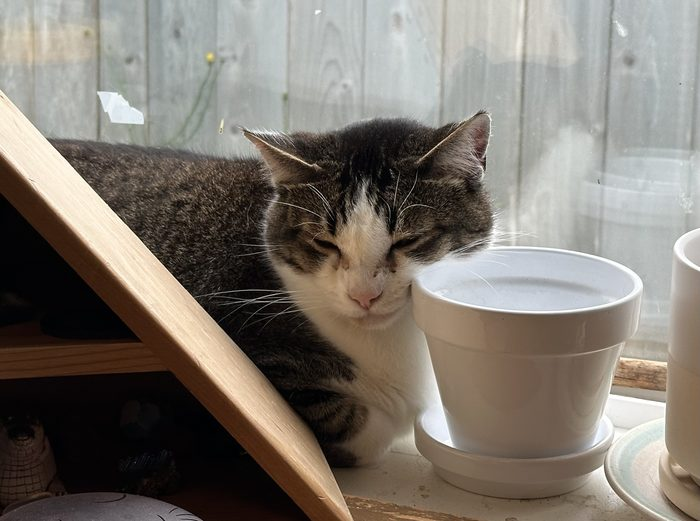
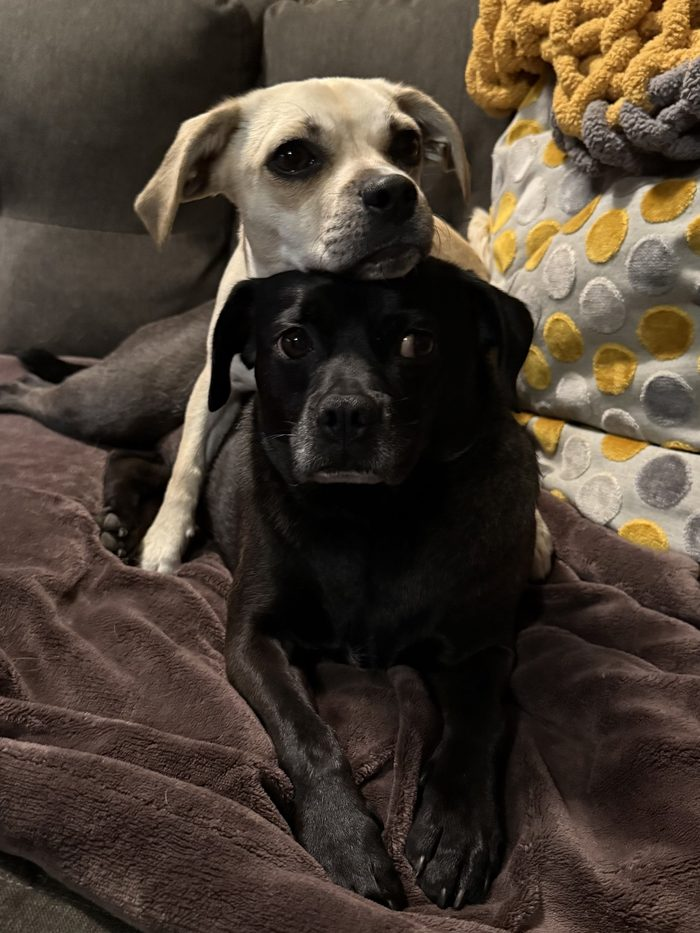
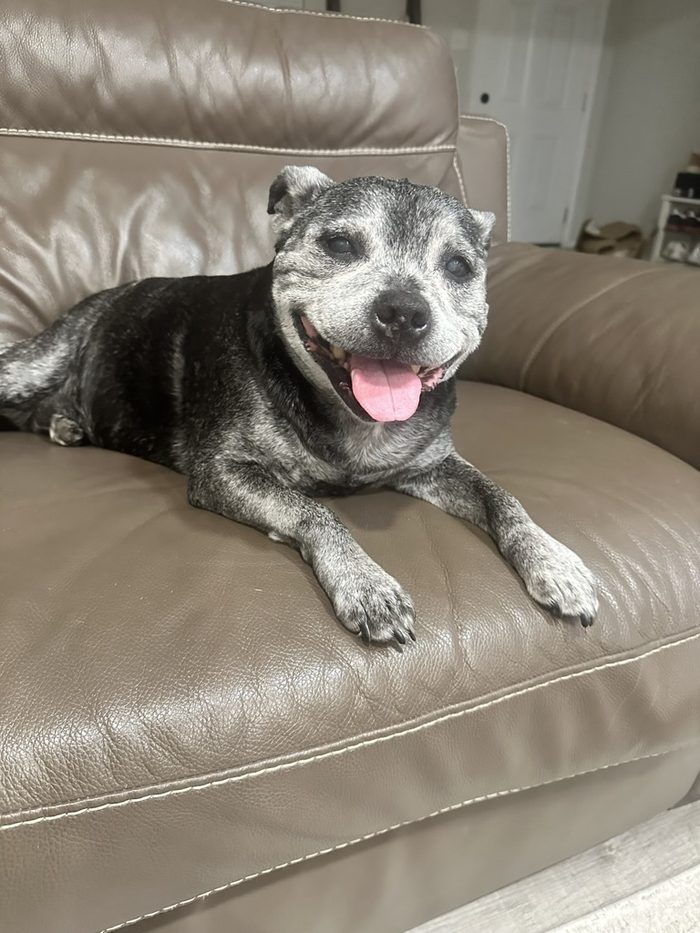

Congrats on finishing Homework 4!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()

### Submission
1. Run `grader.check_all()` above and make sure all tests pass.
2. **File → Download → Download .ipynb**
3. Upload the `.ipynb` file to the LMS.

_(`grader.export()` does not work on Google Colab, so it has been removed.)_